In [1]:
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pandas as pd
import time
from tqdm import tqdm
import uproot

In [2]:
def is_valid_file(path):
    path = Path(path)
    return path.is_file() and path.stat().st_size > 0

In [3]:
parent = "/home/xzcapnai/hepattn/hepattn/src/hepattn/experiments/mu3e/data/conf14"
file_path = "/mu3e_sort_run0001000.root"
in_dir = parent + file_path
out_dir = "/home/xzcapnai/hepattn/hepattn/src/hepattn/experiments/mu3e/data/parquet/run0001000"

tree = uproot.open(Path(in_dir))

### `sorting by events`

In [5]:
def hits_by_event(events, hits, tracks):
    """group hits by their tracks, and then for tracks in an event, group them together"""
    ordered_events = []
    
    for i in tqdm(range(len(events["hit_mc_i"])), desc='grouping'):
        event = hits[events["hit_mc_i"][i]]
        if len(event) == 0:
            continue

        track_id_array = np.array(event["tid"])
        sorted_idx = np.argsort(track_id_array)
        event_sorted = event[sorted_idx]
        track_id_sorted = track_id_array[sorted_idx]

        change_indices = np.flatnonzero(np.diff(track_id_sorted)) + 1

        per_track_hits = np.split(event_sorted, change_indices)
        unique_tids = track_id_sorted[np.r_[0, change_indices]]

        hit_tracks = {tid: hits for tid, hits in zip(unique_tids, per_track_hits)}

        ordered_events.append(hit_tracks)
        
    return ordered_events

def sort_hits_by_event(in_dir: str):
    """preprocess ROOT files into parquet files"""
    root_path = Path(in_dir)
    tree = uproot.open(root_path)
    
    # unpacking relevant ROOT TTrees
    event_idx = tree["mu3e"].arrays('hit_mc_i', library='ak')
    hits = tree["mu3e_mchits"].arrays(library='ak')
    tracks = tree["mu3e_mc_tracks"].arrays(library='ak')
    
    order = np.argsort(tracks['tid'])
    ordered_tracks = tracks[order]
    
    ordered_events = hits_by_event(event_idx, hits, tracks)
    return ordered_events, ordered_tracks

In [6]:
ordered_events = sort_hits_by_event(in_dir)

grouping: 100%|██████████| 50000/50000 [02:46<00:00, 300.62it/s]


In [7]:
ordered_events_list, ordered_tracks = ordered_events

### `sorting by tracks`

In [45]:
def hits_by_track(tracks):
    """group hits by associated tracks"""
    # extracts track ids from each hit
    track_ids = np.array(hits['tid'])
    
    # returns indices that would sort track_ids into ascending order
    sorted_idx = np.argsort(track_ids)
    
    # sorts hits and track_ids into ascending order
    hits_sorted = hits[sorted_idx]
    sorted_track_ids = track_ids[sorted_idx]
    
    # calculates index where track_ids array changes from one array to another - boundary between hits of different tracks
    change_indices = np.flatnonzero(np.diff(sorted_track_ids)) + 1

    # gives unique track ids in order
    unique_tids = sorted_track_ids[np.r_[0, change_indices]]
    slices = np.r_[0, change_indices, len(hits_sorted)]
    grouped_hits = {tid: hits_sorted[slices[i]:slices[i+1]] for i, tid in tqdm(enumerate(unique_tids))}
    
    return grouped_hits

def sort_hits_by_track(in_dir: str):
    """preprocess ROOT files into parquet files"""
    root_path = Path(in_dir)
    tree = uproot.open(root_path)
    
    # unpacking relevant ROOT TTrees
    hits = tree["mu3e_mchits"].arrays(library='ak')
    tracks = tree["mu3e_mc_tracks"].arrays(library='ak')
    
    ordered_events = hits_by_track(hits, tracks)
    return ordered_events

In [46]:
grouped_hits = sort_hits_by_track(in_dir)

1758451it [03:12, 9113.24it/s] 


In [48]:
keys = list(grouped_hits.keys())
print(keys[:20])

[8, 13, 21, 22, 30, 38, 40, 46, 47, 63, 69, 73, 74, 80, 81, 86, 92, 100, 101, 121]


### `parquet`

In [14]:
parent = "/home/xzcapnai/hepattn/hepattn/src/hepattn/experiments/mu3e/data/conf14"
file_path = "/mu3e_sort_run0001000.root"
in_dir = parent + file_path
out_dir = "/home/xzcapnai/hepattn/hepattn/src/hepattn/experiments/mu3e/data/parquet/run0001000"

def hits_by_event(events, hits, tracks):
    """group hits by their tracks, and then for tracks in an event, group them together"""
    ordered_events = []
    
    for i in tqdm(range(len(events["hit_mc_i"])), desc='grouping'):
        event = hits[events["hit_mc_i"][i]]
        if len(event) == 0:
            continue

        track_id_array = np.array(event["tid"])
        sorted_idx = np.argsort(track_id_array)
        event_sorted = event[sorted_idx]
        track_id_sorted = track_id_array[sorted_idx]

        change_indices = np.flatnonzero(np.diff(track_id_sorted)) + 1

        per_track_hits = np.split(event_sorted, change_indices)
        unique_tids = track_id_sorted[np.r_[0, change_indices]]

        hit_tracks = {tid: hits for tid, hits in zip(unique_tids, per_track_hits)}

        ordered_events.append(hit_tracks)
        
    return ordered_events

def event_to_table(event, ordered_tracks):   
    hit_data = []
    #for track_id, hit_array in tqdm(event.items()):
    for track_id, hit_array in event.items():
        for hit in hit_array:
            hit_data.append({
                "truth_tID": int(track_id),
                "hitID": int(hit["hid"]),
                "x": float(hit["x"]),
                "y": float(hit["y"]),
                "z": float(hit["z"]),
                "det": int(hit["det"]),
                "time": float(hit["time"]),
                "edep": float(hit["edep"]),
                "px": float(hit["px"]),
                "py": float(hit["py"]),
                "pz": float(hit["pz"])
            })


    ordered_track_ids = ordered_tracks['tid']
    track_data = []
    #for track_id in tqdm(event_0.keys()):
    for track_id in event.keys():
        idx = np.searchsorted(ordered_track_ids, track_id)
        track = ordered_tracks[idx]

        track_data.append({
                "tid": int(track["tid"]),
                "pdg": int(track["pdg"]),
                "vx": float(track["vx"]),
                "vy": float(track["vy"]),
                "vz": float(track["vz"]),
                "vt": float(track["vt"]),
                "px": float(track["px"]),
            "py": float(track["py"]),
            "pz": float(track["pz"])
        })
        
    return hit_data, track_data

def save_to_parquet(i, hit_data, track_data, out_dir):
    pd.DataFrame(hit_data).to_parquet(f'{out_dir}/event_{i}_hits.parquet')
    pd.DataFrame(track_data).to_parquet(f'{out_dir}/event_{i}_tracks.parquet')

In [15]:
def preprocess(in_dir:str, file_name:str, out_dir:str):
    """preprocess ROOT files into parquet files"""
    root_path = Path(in_dir)
    tree = uproot.open(root_path)
    
    # unpacking relevant ROOT TTrees
    event_idx = tree["mu3e"].arrays('hit_mc_i', library='ak')
    hits = tree["mu3e_mchits"].arrays(library='ak')
    tracks = tree["mu3e_mc_tracks"].arrays(library='ak')
    
    # sorting tracks
    order = np.argsort(tracks['tid'])
    ordered_tracks = tracks[order]
    
    ordered_events = hits_by_event(event_idx, hits, tracks)
    
    for i, event in tqdm(enumerate(ordered_events), total=len(ordered_events), desc='events'):
        hit_data, track_data = event_to_table(event, ordered_tracks)
        #save_to_parquet(i, hit_data, track_data, out_dir)

In [16]:
preprocess(in_dir, 's', out_dir)

events:   2%|▏         | 1244/49975 [01:28<57:52, 14.03it/s]  


KeyboardInterrupt: 

In [64]:
i=10
event_0 = ordered_events_list[i]
hit_data, track_data = event_to_table(event_0, ordered_tracks)
save_to_parquet(i, hit_data, track_data, out_dir)

In [71]:
event_0[8247]

array([(10, 8247, -11, 1, 0, 0.02503001, 9022.55196442, 18.47331874, 15.68105229, 27.68788113, 16.30467584, 15.09499222, -13.86588755, 26.19590047),
       (10, 8247, -11, 2, 0, 0.01643941, 9022.57565679, 22.88061013, 19.92432163, 24.08505459, 15.74474851, 16.2245568 , -13.13534985, 26.1520914 )],
      dtype=[('det', '<i4'), ('tid', '<i4'), ('pdg', '<i4'), ('hid', '<i4'), ('hid_g', '<i4'), ('edep', '<f8'), ('time', '<f8'), ('x', '<f8'), ('y', '<f8'), ('z', '<f8'), ('px', '<f8'), ('py', '<f8'), ('pz', '<f8'), ('e', '<f8')])

In [37]:
import pandas as pd
import pyarrow.parquet

In [65]:
out_dir = "/home/xzcapnai/hepattn/hepattn/src/hepattn/experiments/mu3e/data/parquet/run0001000/"
event_0_hits = Path(out_dir + 'event_0_hits.parquet')
event_0_tracks = Path(out_dir + 'event_0_tracks.parquet')

trackml_out_dir = "/home/xzcapnai/hepattn/hepattn/src/hepattn/experiments/trackml/data/prepped/test/"
trackml_event_0_hits = Path(trackml_out_dir + 'event000029800-hits.parquet')
trackml_event_0_parts = Path(trackml_out_dir + 'event000029800-parts.parquet')

In [66]:
def read_parquet_schema_df(uri: str) -> pd.DataFrame:
    """Return a Pandas dataframe corresponding to the schema of a local URI of a parquet file.

    The returned dataframe has the columns: column, pa_dtype
    """
    # Ref: https://stackoverflow.com/a/64288036/
    schema = pyarrow.parquet.read_schema(uri, memory_map=True)
    schema = pd.DataFrame(({"column": name, "pa_dtype": str(pa_dtype)} for name, pa_dtype in zip(schema.names, schema.types)))
    schema = schema.reindex(columns=["column", "pa_dtype"], fill_value=pd.NA)  # Ensures columns in case the parquet file has an empty dataframe.
    return schema

In [67]:
event_0_hits_schema = read_parquet_schema_df(event_0_hits)
trackml_event_0_hits_schema = read_parquet_schema_df(trackml_event_0_hits)

event_0_tracks_schema = read_parquet_schema_df(event_0_tracks)
trackml_event_0_parts_schema = read_parquet_schema_df(trackml_event_0_parts)

In [68]:
print(event_0_hits_schema)
print()
print(trackml_event_0_hits_schema)

       column pa_dtype
0   truth_tID    int64
1       hitID    int64
2           x   double
3           y   double
4           z   double
5         det    int64
6        time   double
7        edep   double
8          px   double
9          py   double
10         pz   double

            column pa_dtype
0           hit_id    int64
1                x   double
2                y   double
3                z   double
4        volume_id    int64
5         layer_id    int64
6        module_id    int64
7      particle_id    int64
8               tx   double
9               ty   double
10              tz   double
11             tpx   double
12             tpy   double
13             tpz   double
14          weight   double
15      charge_sum   double
16  channel_counts    int64
17     charge_frac   double
18      cell_count   double
19        cell_val   double
20            leta   double
21            lphi   double
22              lx   double
23              ly   double
24              lz   do

In [45]:
print(event_0_tracks_schema)
print()
print(trackml_event_0_parts_schema)

  column pa_dtype
0    tid    int64
1    pdg    int64
2     vx   double
3     vy   double
4     vz   double
5     vt   double
6     px   double
7     py   double
8     pz   double

          column pa_dtype
0    particle_id    int64
1  particle_type    int64
2             vx   double
3             vy   double
4             vz   double
5             px   double
6             py   double
7             pz   double
8              q    int64
9          nhits    int64


### `event plotting`

In [54]:
def plot_event(event):
    """
    Plot hit positions for a single event.
    
    Parameters:
    -----------
    event : awkward array
        Single event data containing hit position information
    """
    # Extract hit positions (adjust field names based on your data structure)
    x = ak.concatenate([event[key]['x'] for key in event.keys()])
    y = ak.concatenate([event[key]['y'] for key in event.keys()])
    z = ak.concatenate([event[key]['z'] for key in event.keys()])
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, 3, figsize=(20,6.5))
    
    # XY projection
    axes[0].scatter(x, y, alpha=0.8, s=10)
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    axes[0].set_title('XY Projection')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(-100,100)
    axes[0].set_ylim(-100,100)
    
    # XZ projection
    axes[1].scatter(z, x, alpha=0.8, s=10)
    axes[1].set_xlabel('z')
    axes[1].set_ylabel('x')
    axes[1].set_title('XZ Projection')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(-100,100)

    
    # YZ projection
    axes[2].scatter(z, y, alpha=0.8, s=10)
    axes[2].set_xlabel('z')
    axes[2].set_ylabel('y')
    axes[2].set_title('YZ Projection')
    axes[2].grid(True, alpha=0.3)
    axes[2].set_ylim(-100,100)

    
    plt.tight_layout()
    plt.show()
    
    print(f"Number of hits: {len(x)}")

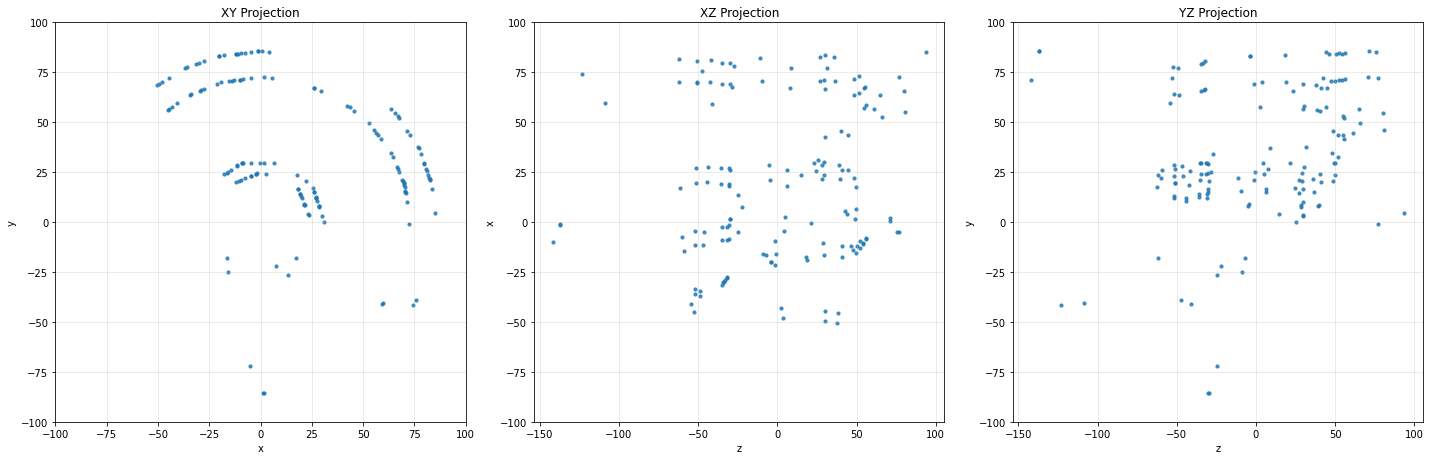

Number of hits: 148


In [55]:
plot_event(event_0)

### `batch preprocessing`

In [ ]:
def process_mu3e_data(in_dir:str, out_dir:str, tracks_per_fake_event: int=25, event_limit=None):
    path_in = Path(in_dir)
    path_out = Path(out_dir)
    
    print(f'opening {path_in.name}...')
    
    # 1. READ DATA ------------------------------------------------------------------------------------------
    with uproot.open(path_in) as file:
        # B. get tracks table (global list)
        print('loading tracks table...')
        track_fields = ["tid", "pdg", "vx", "vy", "vz", "vt", "px", "py", "pz"]
        tracks_flat = file['mu3e_mc_tracks'].array(track_fields, library='ak')
        
    # convert to Pandas DataFrames for fast manipulation
    df_tracks_global = ak.to_dataframe(tracks_flat)
    
    # 2. APPLY TEST LIMIT -----------------------------------------------------------------------------------
    if event_limit:
        track_limit = event_limit * tracks_per_fake_event
        print(f'TEST : limiting to first {event_limit} compiled events...')
        df_tracks_global = df_tracks_global.head(track_limit)
    
    # 3. CREATE FAKE EVENTS ---------------------------------------------------------------------------------
    print(f'compiling {len(df_tracks_global)} tracks into fake events of size {tracks_per_fake_event}...')
    
    # calculate total number of tracks
    N_tracks = len(df_tracks_global)
    N_chunks = N_tracks // tracks_per_fake_event + 1
    chunk_ids = np.arange(N_chunks)
    fake_event_ids = np.repeat(chunk_ids, tracks_per_fake_event)[:N_tracks]
    
    # add fake_event_ids to tracks DataFrame
    df_tracks_global['event_id'] = fake_event_ids
    df_tracks_final = df_tracks_global.sort_values(by='event_id')
    
    # 4. LINK HITS TO EVENTS --------------------------------------------------------------------------------
    hit_cols = ['tid', 'hid', 'x', 'y', 'z', 'time', 'edep', 'px', 'py', 'pz']
    print('iterating through hits table, linking to events...')
    
    all_hits_data = []
    
    # iterate over large hits table 
    for df_hits_chunk in tqdm(
        uproot.iterate(f'{in_dir}:mu3e_mchits',
                       expressions=hit_cols,
                       library='pd',
                       step_size=500000),
        desc='processing hit chunks'):
        
        df_hits_chunk = df_hits_chunk.rename(columns={'tid':'trackID', 'hid':'hitID'})
        
        # MERGE: join hits chunk w/ full tracks dataframe
        df_merged_chunks = pd.merge(
            df_hits_chunk,
            df_tracks_final[['tid', 'event_id']],
            left_on='trackID',
            right_on='tid',
            how='inner')
        
        if df_merged_chunk.empty and test_limit_events:
            break
        
        df_merged_chunk = df_merged_chunk.drop(columns=['tid'])
        all_hits_data.append(df_merged_chunk)
        
    # 5. FINAL ASSEMBLY AND SAVE ----------------------------------------------------------------------------
    print('assembling final hits dataframe...')
    df_hits_final = pd.concat(all_hits_data, ignore_index=True)
    df_hits_final = df_hits_final.sort_values(by='event_id')
    
    N_fake_events = df_tracks_final['event_id'].max() + 1
    
    # save Outputs
    df_hits_final.to_parquet(
        path_out / "hits_compiled_tracks.parquet", 
        engine='pyarrow', compression='snappy', index=False
    )
    df_tracks_final.to_parquet(
        path_out / "tracks_compiled_events.parquet", 
        engine='pyarrow', compression='snappy', index=False
    )
    
    print("\n--- Done ---")
    print(f"Result: {len(df_tracks_final)} tracks compiled into {N_fake_events} fake events.")

### `streamlining preprocessing`

In [5]:
def load_real_event_data(path_in, path_out):
    print('Loading global hit and track data, compiling events...')
    track_fields = ["tid", "pdg", "vx", "vy", "vz", "vt", "px", "py", "pz"]
    hit_fields = ["tid", "hid", "det", "pdg", "x", "y", "z", "time", "edep", "px", "py", "pz"]
    
    with uproot.open(Path(in_dir)) as file:
        # pd.DataFrame of track and hit data from mu3e tree - only with chosen fields
        tracks_flat = file['mu3e_mc_tracks'].arrays(track_fields, library="pd")
        hits_flat = file['mu3e_mchits'].arrays(hit_fields, library="pd")

        # jagged awkward array - each entry in jagged array = list of hit indices in mchits tree, each list = one event
        hit_mapping = file["mu3e"]["hit_mc_i"].array(library='ak') 

    # dataframe tidying    
    global_track_df = tracks_flat.rename(columns={'tid': 'trackID'})
    global_hit_df = hits_flat.rename(columns={"tid": "trackID", "hid": "hitID"})
        
    return global_track_df, global_hit_df, hit_mapping

In [6]:
def even_finaler_preprocessing(in_dir: str, out_dir: str, event_limit: int=None):
    """
    Convert ROOT file to 2 parquet files (tracks and hits) with original eventID column.
    For hits without an associated event, assigns eventID : -1.
    """   
    path_in = Path(in_dir)
    path_out = Path(out_dir)
    path_out.mkdir(parents=True, exist_ok=True)
    
    # loading hit and track dataframes
    global_track_df, global_hit_df, hit_mapping = load_real_event_data(path_in, path_out)

    # mapping events
    print('Mapping events...')
    # flattening into one long numpy array of hit indices - all the hits in mchits that are included in monte carlo eventing
    flat_indices = np.asarray(ak.flatten(hit_mapping), dtype=np.int64)

    # creates array of eventIDs - maps onto flat_indices --- first N entries in event_ids = 0, maps to first N hit indices in flat_indices
    event_ids = np.repeat(np.arange(len(hit_mapping)), ak.num(hit_mapping))

    # above misses out all events that aren't accounted for in the mu3e tree - below assigns those events eventID = -1 -- makes easy to filter out later
    full_event_ids = np.full(len(global_hit_df), -1, dtype=np.int32)   # array of -1, length = total number of hits
    full_event_ids[flat_indices] = event_ids                           # applies eventIDs to all hit idx
    global_hit_df['eventID'] = full_event_ids                          # applied eventIDs to all hits in global hit dataframe

    tid_to_event = global_hit_df[global_hit_df['eventID'] != -1].set_index('trackID')['eventID']
    tid_to_event = tid_to_event[~tid_to_event.index.duplicated(keep='first')]
    global_track_df['eventID'] = global_track_df['trackID'].map(tid_to_event).fillna(-1).astype(int)
    
    # applying event limit
    if event_limit:
        print(f'Limiting to {event_limit} compiled events...')
        global_hit_df = global_hit_df[global_hit_df["eventID"] < event_limit]
        global_track_df = global_track_df[global_track_df["eventID"] < event_limit]
        print('Ordering dataframes...')
    else:
        print('Ordering dataframes...')
        
    # sorting eventID and trackID
    global_hit_df = global_hit_df.sort_values(['eventID', 'trackID']).reset_index(drop=True)
    global_track_df = global_track_df.sort_values(['eventID', 'trackID']).reset_index(drop=True)
    
    # Save to single parquet files
    print("Saving tracks to parquet...")
    global_track_df.to_parquet(path_out / "all_tracks.parquet", index=False)
    
    print("Saving hits to parquet...")
    global_hit_df.to_parquet(path_out / "all_hits.parquet", index=False)
    
    print("\n--- Done ---")
    print(f"Saved {len(global_track_df['eventID'].unique())} events to:")
    print(f"  - {path_out / 'all_tracks.parquet'}")
    print(f"  - {path_out / 'all_hits.parquet'}")
    
    return global_track_df, global_hit_df

In [4]:
parent = "/home/xzcapnai/hepattn/hepattn/src/hepattn/experiments/mu3e/data/conf14"
file_path = "/mu3e_sort_run0001000.root"
in_dir = parent + file_path
out_dir = "/home/xzcapnai/hepattn/hepattn/src/hepattn/experiments/mu3e/data/parquet/run0001000"

print('Loading global hit and track data...')
track_fields = ["tid", "pdg", "vx", "vy", "vz", "vt", "px", "py", "pz"]
hit_fields = ["tid", "hid", "det", "pdg", "x", "y", "z", "time", "edep", "px", "py", "pz"]

with uproot.open(Path(in_dir)) as file:
    # pd.DataFrame of track and hit data from mu3e tree - only with chosen fields
    tracks_flat = file['mu3e_mc_tracks'].arrays(track_fields, library="pd")
    hits_flat = file['mu3e_mchits'].arrays(hit_fields, library="pd")
    
    # jagged awkward array - each entry in jagged array = list of hit indices in mchits tree, each list = one event
    hit_mapping = file["mu3e"]["hit_mc_i"].array(library='ak') 
    
# dataframe tidying    
global_track_df = tracks_flat.rename(columns={'tid': 'trackID'})
global_hit_df = hits_flat.rename(columns={"tid": "trackID", "hid": "hitID"})
print('!!! Loaded !!!')

Loading global hit and track data...
!!! Loaded !!!


In [5]:
print(f'length of flat indices:              {len(np.asarray(ak.flatten(hit_mapping), dtype=np.int64))}')
print(f'number of tracks in global_track_df: {len(global_track_df)}')
print(f'number of hits in global_hit_df:     {len(global_hit_df)}')

length of flat indices:              2977947
number of tracks in global_track_df: 2113976
number of hits in global_hit_df:     28522372


In [167]:
print('Mapping events...')

# flattening into one long numpy array of hit indices - all the hits in mchits that are included in monte carlo eventing
flat_indices = np.asarray(ak.flatten(hit_mapping), dtype=np.int64)

# creates array of eventIDs - maps onto flat_indices --- first 19 entries in event_ids = 0, maps to first 19 hit indices in flat_indices
event_ids = np.repeat(np.arange(len(hit_mapping)), ak.num(hit_mapping))

# above misses out all events that aren't accounted for in the mu3e tree - below assigns those events eventID = -1 --- makes easy to filter out later
full_event_ids = np.full(len(global_hit_df), -1, dtype=np.int32)   # array of -1, length = total number of hits
full_event_ids[flat_indices] = event_ids                           # applies eventIDs to all hit idx
global_hit_df['eventID'] = full_event_ids                          # applied eventIDs to all hits in global hit dataframe

tid_to_event = global_hit_df[global_hit_df['eventID'] != -1].set_index('trackID')['eventID']
tid_to_event = tid_to_event[~tid_to_event.index.duplicated(keep='first')]
global_track_df['eventID'] = global_track_df['trackID'].map(tid_to_event).fillna(-1).astype(int)
print('!!! Mapped !!!')

Mapping events...
!!! Mapped !!!


In [168]:
print('Sorting by event and track...')
global_hit_df = global_hit_df.sort_values(['eventID', 'trackID']).reset_index(drop=True)
global_track_df = global_track_df.sort_values(['eventID', 'trackID']).reset_index(drop=True)
print('!!! Sorted !!!')

Sorting by event and track...
!!! Sorted !!!


In [103]:
NaNevent_hits = global_hit_df[global_hit_df['eventID'] == -1]
NaNevent_tracks = global_track_df[global_track_df['eventID'] == -1]

In [166]:
print(f"unique particle ids:   {np.unique(global_hit_df['pdg'].values).tolist()}")
print("")
print("--------------------------- hit stats ---------------------------")
print(f"electron hits:         {(global_hit_df['pdg'].values == 11).sum()}")
print(f"positron hits:         {(global_hit_df['pdg'].values == -11).sum()}")
print(f"antimuon hits:         {(global_hit_df['pdg'].values == -13).sum()}")
print(f"photon hits:           {(global_hit_df['pdg'].values == 22).sum()}")
print(f"proton hits:           {(global_hit_df['pdg'].values == 2212).sum()}")
print(f"neutron hits:          {(global_hit_df['pdg'].values == 2112).sum()}")
print(f"alpha particle hits:   {(global_hit_df['pdg'].values == 1000020040).sum()}")
print(f"Be nuclide hits:       {(global_hit_df['pdg'].values == 1000040080).sum()}")
print(f"C nuclide hits:        {(global_hit_df['pdg'].values == 1000060120).sum()}")
print(f"Mg nuclide hits:       {(global_hit_df['pdg'].values == 1000120240).sum()}")
print(f"Si nuclide hits:       {(global_hit_df['pdg'].values == 1000140280).sum()}")
print("")
print(f"total hits:            {len(global_hit_df)}")
print("")
print("-------------------------- track stats --------------------------")
print(f"electron tracks:       {(global_track_df['pdg'].values == 11).sum()}")
print(f"positron tracks:       {(global_track_df['pdg'].values == -11).sum()}")
print(f"antimuon tracks:       {(global_track_df['pdg'].values == -13).sum()}")
print(f"photon tracks:         {(global_track_df['pdg'].values == 22).sum()}")
print(f"proton tracks:         {(global_track_df['pdg'].values == 2212).sum()}")
print(f"neutron tracks:        {(global_track_df['pdg'].values == 2112).sum()}")
print(f"alpha particle tracks: {(global_track_df['pdg'].values == 1000020040).sum()}")
print(f"Be nuclide tracks:     {(global_track_df['pdg'].values == 1000040080).sum()}")
print(f"C nuclide tracks:      {(global_track_df['pdg'].values == 1000060120).sum()}")
print(f"Mg nuclide tracks:     {(global_track_df['pdg'].values == 1000120240).sum()}")
print(f"Si nuclide tracks:     {(global_track_df['pdg'].values == 1000140280).sum()}")
print("")
print(f"total tracks:          {len(global_track_df)}")

unique particle ids:   [-13, -11, 11, 22, 2112, 2212, 1000020040, 1000040080, 1000060120, 1000120240, 1000140280]

--------------------------- hit stats ---------------------------
electron hits:         1382468
positron hits:         25232261
antimuon hits:         313047
photon hits:           1594151
proton hits:           23
neutron hits:          392
alpha particle hits:   16
Be nuclide hits:       1
C nuclide hits:        11
Mg nuclide hits:       1
Si nuclide hits:       1

total hits:            28522372

-------------------------- track stats --------------------------
electron tracks:       137699
positron tracks:       541665
antimuon tracks:       517606
photon tracks:         916824
proton tracks:         4
neutron tracks:        166
alpha particle tracks: 6
Be nuclide tracks:     1
C nuclide tracks:      2
Mg nuclide tracks:     1
Si nuclide tracks:     1

total tracks:          2113976


In [60]:
print('---------------- hit indices by event -------------------')
print('event 0', hit_mapping[0], 'length:', len(hit_mapping[0]))
print('event 1', hit_mapping[1], 'length:', len(hit_mapping[1]))
print('event 2', hit_mapping[2], 'length:', len(hit_mapping[2]))
print('event 3', hit_mapping[3], 'length:', len(hit_mapping[3]))
print('event 4', hit_mapping[4], 'length:', len(hit_mapping[4]))
print('event 5', hit_mapping[5], 'length:', len(hit_mapping[5]))
print('event 6', hit_mapping[6], 'length:', len(hit_mapping[6]))
print('event 7', hit_mapping[7], 'length:', len(hit_mapping[7]))
print('event 8', hit_mapping[8], 'length:', len(hit_mapping[8]))
print('event 9', hit_mapping[9], 'length:', len(hit_mapping[9]))
print('event 10', hit_mapping[10], 'length:', len(hit_mapping[10]))
print('event 11', hit_mapping[11], 'length:', len(hit_mapping[11]))

---------------- hit indices by event -------------------
event 0 [5589, 5590, 5591, 5592, 5593, 5594, 5595, ... 5602, 5603, 5604, 5605, 5606, 5607] length: 19
event 1 [5724, 5725, 5726, 5727, 5728, 5729, 5730, 5731, 5732, 5733] length: 10
event 2 [5826, 5827, 5828, 5829, 5830, 5831, 5832, ... 5968, 5969, 5970, 5971, 5972, 5973] length: 148
event 3 [6878, 6879, 6880, 6881, 6882, 6883, 6884, ... 6984, 6985, 6986, 6987, 6988, 6989] length: 110
event 4 [7387, 7388, 7389, 7390, 7391, 7392, 7393, ... 7407, 7408, 7409, 7410, 7552, 7576] length: 26
event 5 [7549, 7550, 7551, 7553, 7554, 7555, 7556, ... 7662, 7663, 7664, 7665, 7666, 7667] length: 117
event 6 [8093, 8094, 8095, 8096, 8097, 8098, 8099, ... 8173, 8174, 8512, 8516, 8520, 8521] length: 86
event 7 [8485, 8486, 8487, 8488, 8489, 8490, 8491, ... 8570, 8571, 8572, 8573, 8574, 8575] length: 87
event 8 [9025, 9026, 9027, 9028, 9029, 9030, 9031, ... 9050, 9051, 9196, 9201, 9204, 9212] length: 31
event 9 [9194, 9195, 9197, 9198, 9199, 9200

In [173]:
global_hit_df[global_hit_df["pdg"]==-13]

,trackID,hitID,det,pdg,x,y,z,time,edep,px,py,pz,eventID
30,13,0,90,-13,11.073321,-1.602243,-20.517843,2.097560e+02,0.000000,0.000000,0.000000,-0.000000,-1
76,40,0,90,-13,10.183298,-0.313401,-23.192420,2.044608e+02,0.000000,0.000000,-0.000000,0.000000,-1
105,47,0,90,-13,-6.240615,-3.555553,31.064675,1.813346e+02,0.000000,-0.000000,-0.000000,0.000000,-1
106,63,0,90,-13,3.569605,4.482184,-34.896518,8.316098e+01,0.000000,0.000000,-0.000000,0.000000,-1
128,74,0,90,-13,2.568113,-4.893667,-35.411128,7.989465e+01,0.000000,0.000000,0.000000,0.000000,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28387342,19939154,1,10,-13,0.632771,-24.706521,-35.991047,7.076984e+06,0.263936,0.563075,-5.839506,4.628922,47741
28404968,22004085,1,10,-13,13.161598,19.516911,-21.893112,7.811000e+06,1.279077,-0.814725,10.274828,12.872085,48044
28413733,22947004,1,10,-13,14.965327,18.769782,-27.506152,8.144174e+06,0.466556,-1.035972,7.592054,6.332157,48182
28448856,26970127,1,10,-13,-19.875389,12.296155,-35.810261,9.569064e+06,1.211325,-8.103677,0.433286,15.602142,48773


In [174]:
global_track_df[global_track_df["pdg"]==-13]

,trackID,pdg,vx,vy,vz,vt,px,py,pz,eventID
1,1,-13,5.108071,10.581840,-1000.0,3.380372e+01,2.127031,-1.493362,26.360422,-1
3,13,-13,5.706729,-0.515453,-1000.0,1.948671e+02,-2.007502,-0.239049,27.813429,-1
6,27,-13,7.193956,-0.894915,-1000.0,4.837026e+01,-1.439813,1.045593,27.347849,-1
8,31,-13,3.616942,-0.869910,-1000.0,2.197049e+02,-3.531376,-0.335663,27.327350,-1
10,40,-13,8.521625,3.358379,-1000.0,1.889551e+02,2.380942,-0.093125,26.873151,-1
...,...,...,...,...,...,...,...,...,...,...
2098839,19939154,-13,-1.256308,-1.143241,-1000.0,7.076969e+06,-1.124983,-1.305245,27.968067,47741
2100809,22004085,-13,-4.162801,-9.679408,-1000.0,7.810985e+06,0.133985,1.780426,28.374516,48044
2101850,22947004,-13,0.478644,7.346223,-1000.0,8.144159e+06,2.644334,-0.341869,27.312898,48182
2105799,26970127,-13,-2.478009,-0.774514,-1000.0,9.569051e+06,3.645367,0.706482,29.276684,48773
